# Curve Fitting and the Chi-Squared Test

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.optimize import curve_fit
from scipy import stats

## Some Fake Data First:

Let's say a person goes on a diet where they lose 3 pounds in 30 days, at a steady rate of 0.1 pounds per day. They weigh themselves every three days. The scale that they use has a random error associated with it of plus or minus one pound. Let's generate some data to represent this:

In [2]:
#These will be the true x and y values for day and weight.
x=np.arange(0,33,3)
ytrue=-0.1*x+150
print (x)
print (ytrue)

[ 0  3  6  9 12 15 18 21 24 27 30]
[150.  149.7 149.4 149.1 148.8 148.5 148.2 147.9 147.6 147.3 147. ]


In [3]:
#Now we add randomly generated errors to y, with a standard deviation of one pound.
rng = default_rng(seed=222) #use a fixed seed here so everyone gets the same random data.
yerror = np.full_like(ytrue,1.0)
ynoise = rng.normal(loc=0.0,scale=yerror[0],size=len(x))
yobs = ytrue + ynoise

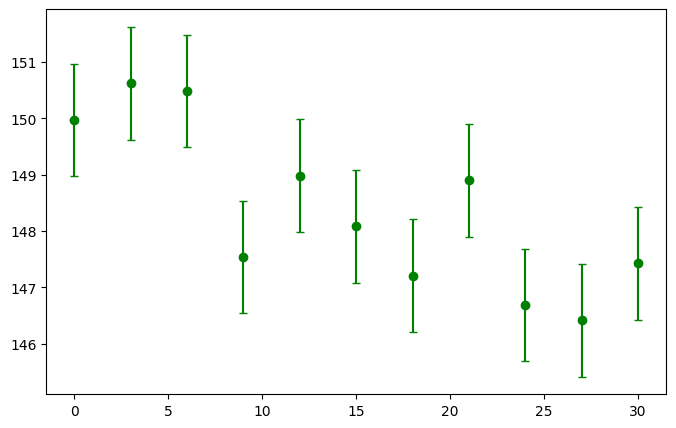

In [4]:
#Plot the data with the associated plus or minus one pound error bars.
plt.figure(figsize=(8,5))
plt.errorbar(x,yobs,yerr=yerror,color='green',capsize=3,fmt="o")
plt.show()

We want to know if the person can conclusively detect any weight loss from these data, given the precision of the scale that they used. We will first fit a constant to these data, and then check the "goodness" of the fit. If a constant is a poor fit, then we can proceed to something else like a linear fit. We will use the routine **curve_fit** from scipy.optimize to fit functions to data.

In [5]:
#The constant fit.

def f(x, a): #We must define a function for curve_fit to fit. This is just the constant function y=a.
    return a

#Curve fit returns the parameters of the fit and the "covariance matrix",
#from which we can get the errors of the fit parameters. The variable "pars" will be an
#array containing all of the fit parameters, in this case it is just the constant a.

pars, cov = curve_fit(f, x, yobs, sigma=yerror, absolute_sigma=True)

a = pars
ycalc = np.full_like(yobs,a)

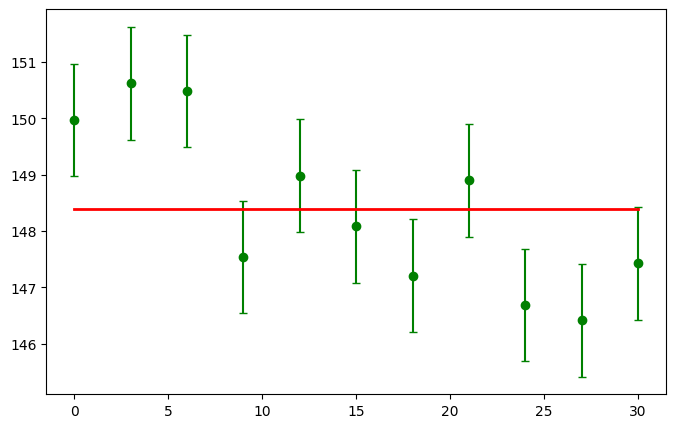

In [6]:
#Plot the constant fit.
plt.figure(figsize=(8,5))
plt.errorbar(x,yobs,yerr=yerror,color='green',capsize=3,fmt="o")
plt.plot(x,ycalc,color='red',linewidth=2)
plt.show()

## Goodness of fit:
To compute how well a given function fits the data, we will use the chi-squared statistic. It is defined according to the formula below. We will then compute the probability of getting a chi-squared value as large or larger than what we actually obtained by random chance alone. If this probabbility (called the "significance") is very low (often < 0.05 is used), then we can reject the function that we used as providing a good fit to the data.

<img src='https://drive.google.com/uc?export=view&id=1M1GrlkkLt7g9ZDFiyU2ccO3wOBqaw1SF' align="left" width="850" height="550"/>

In [7]:
#Significance of the constant fit.
#To compute the probabbility we must compute both the chi-squared value (defined above),
#and the number of "degrees of freedom", which is the number of data points minus the number
#of fit paramters (which is one for a constant).

chisqr = np.sum((yobs-ycalc)**2/yerror**2) #the chi-squared value, from the formula above
dof = yobs.shape[0]-1 #the number of degrees of freedom fit parameter 1 for constant 2 for line

# the stats.chi2.cdf routine returns the probability of getting the observed chi-squared value or lower,
# so one minus that value if the probability of getting the observed chi-squared value or higher.
# which is defined as the "significance of the fit"

significance = 1.0-stats.chi2.cdf(chisqr, dof)
print (round(significance,3))

#In this case we find that the significance is very low (much less that 0.05), so we can reject
#the constant fit.

0.013


In [8]:
#We now try a linear fit using the same procedure, fitst call curve_fit to get the fit parameters,
#then plot the linear fit, then compute the chi-squared and the significance.

def f(x, a, b):
    return a + b*x

pars, cov = curve_fit(f, x, yobs, sigma=yerror, absolute_sigma=True)
a, b = pars #This uses unpacking of a one-dimensional array.

#The error on the fit parameters is specified to be the square root of the diagonal elements of
#the "covariance matrix" returned by the curve_fit routine.
nsigma = np.sqrt(np.diag(cov))

ycalc = a + b*x
print (round(pars[1],2), "+/-", round(nsigma[1],2)) #this is the computed weight loss rate and its error.

-0.12 +/- 0.03


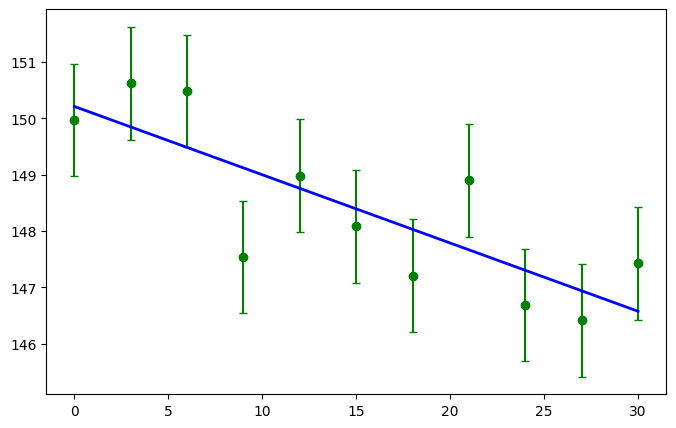

In [9]:
#Plot the linear fit.
plt.figure(figsize=(8,5))
plt.errorbar(x,yobs,yerr=yerror,linestyle='none',color='green',capsize=3,fmt="o")
plt.plot(x,ycalc,color='blue',linewidth=2)
plt.show()

In [10]:
#Significance of the linear fit.
chisqr = np.sum((yobs-ycalc)**2/yerror**2)
dof = yobs.shape[0]-2
significance = 1.0-stats.chi2.cdf(chisqr, dof)
print (round(significance,3))

#Since the probability below if not very low, we can conclude that a linear weight loss over time provides an
#adequate description of our data. That does not necessarily mean that it is true, just that we cannot justify
#fitting a function with more parameters based on the data that we have.

0.545


## Some Real Data:

The csv file that we read below contains data on the measured separation of a blob of plasma from the core in the jet of the quasar 1101+384 versus time. This
is one of the quasars whose image we plotted back in Notebook 5. (You might want to review Notebook 5 now.)

The measured separation is given in light-years, and the estimated error on measuring the separation is plus or minus 0.28 light-years in this case.

The goal is to see whether we detect significant motion in this component, or whether a constant provides an adequate fit. If we detect motion, we would like to know its speed, which will be the slope of the linear fit.

In [11]:
from google.colab import drive
drive.mount ('/content/drive')
motiondf = pd.read_csv('drive/My Drive/Notebook15/1101+384data.csv')
motiondf

Mounted at /content/drive


,Decimal_Date,Separation,Error
0,1994.30,2.266,0.28
1,1994.32,2.756,0.28
2,1995.27,3.118,0.28
3,1995.79,2.542,0.28
4,1996.31,2.600,0.28
5,1996.37,2.304,0.28
6,1996.88,3.164,0.28
7,1997.08,2.884,0.28
8,1997.20,2.686,0.28
9,1997.25,2.980,0.28


In [12]:
x= motiondf.Decimal_Date.to_numpy()
yobs = motiondf.Separation.to_numpy()
yerror = motiondf.Error.to_numpy()

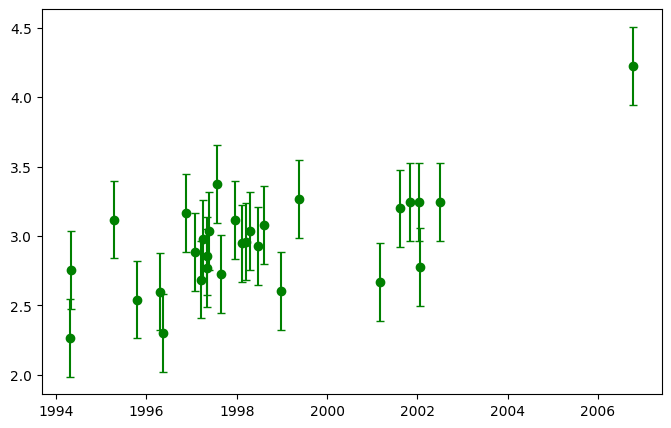

In [13]:
plt.figure(figsize=(8,5))
plt.errorbar(x,yobs,yerr=yerror,color='green',capsize=3,fmt="o")
plt.show()

In [14]:
#The constant fit.

def f(x, a):
    return a

pars, cov = curve_fit(f, x, yobs, sigma=yerror, absolute_sigma=True)
a = pars
ycalc = np.full_like(yobs,a)

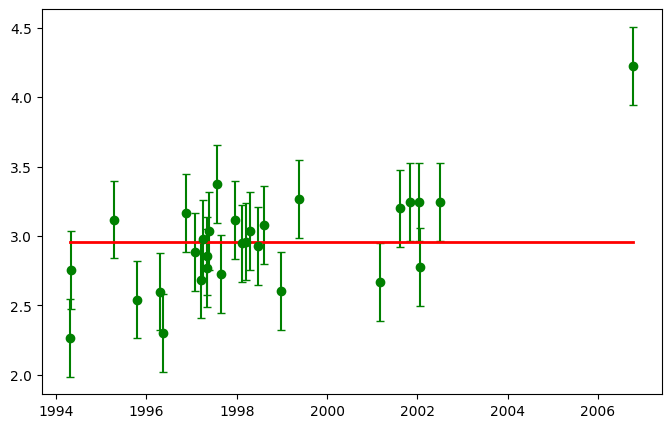

In [15]:
#Plot the constant fit.
plt.figure(figsize=(8,5))
plt.errorbar(x,yobs,yerr=yerror,color='green',capsize=3,fmt="o")
plt.plot(x,ycalc,color='red',linewidth=2)
plt.show()

In [16]:
#Significance of the constant fit.
chisqr = np.sum((yobs-ycalc)**2/yerror**2)
dof = yobs.shape[0]-1
significance = 1.0-stats.chi2.cdf(chisqr, dof)
print (round(significance,3))

0.008


In [17]:
#Proceed to linear fit.

def f(x, a, b):
    return a + b*x

pars, cov = curve_fit(f, x, yobs, sigma=yerror, absolute_sigma=True)
a, b = pars
nsigma = np.sqrt(np.diag(cov))
ycalc = a + b*x
print (round(pars[1],2), "+/-", round(nsigma[1],2))
#The calculated speed comes out to be 9% plus or minus 2% of the speed of light. This measurement is published in
#Piner, Pant, and Edwards (2010), Table 5 (linked below).

0.09 +/- 0.02


### The published [measurement](https://iopscience.iop.org/article/10.1088/0004-637X/723/2/1150#apj368273t5) (includes a Whittier student author).

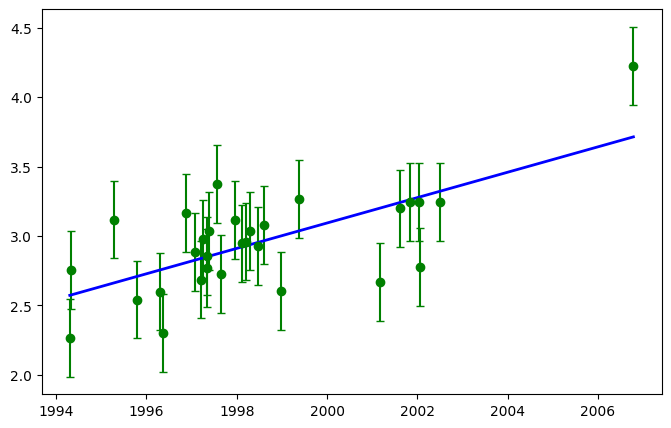

In [18]:
#Plot the linear fit.
plt.figure(figsize=(8,5))
plt.errorbar(x,yobs,yerr=yerror,linestyle='none',color='green',capsize=3,fmt="o")
plt.plot(x,ycalc,color='blue',linewidth=2)
plt.show()

In [19]:
#Significance of the linear fit.
chisqr = np.sum((yobs-ycalc)**2/yerror**2)
dof = yobs.shape[0]-2
significance = 1.0-stats.chi2.cdf(chisqr, dof)
print (round(significance,3))
#We find that a linear fit provides an adequate fit to the data.

0.477


## Some more real data:
The csv file that we read below contains data on the measured separation of a blob of plasma from the core in the jet of the quasar 1642+690 versus time.

In this case the estimated error on measuring the separation is plus or minus 0.15.

Once again the goal is to see whether we detect significant motion in this component, and if we do whether or not linear motion provides an adequate fit.

In [20]:
motiondf = pd.read_csv('drive/My Drive/Notebook15/1642+690data.csv')
motiondf

,Decimal_Date,Separation,Error
0,1999.97,1.453,0.15
1,2000.08,1.487,0.15
2,2000.20,1.532,0.15
3,2000.39,1.702,0.15
4,2000.51,1.477,0.15
5,2000.81,1.467,0.15
6,2000.93,1.426,0.15
7,2001.08,1.440,0.15
8,2001.19,1.514,0.15
9,2001.27,1.494,0.15


In [21]:
x=motiondf.Decimal_Date.to_numpy()
yobs = motiondf.Separation.to_numpy()
yerror = motiondf.Error.to_numpy()

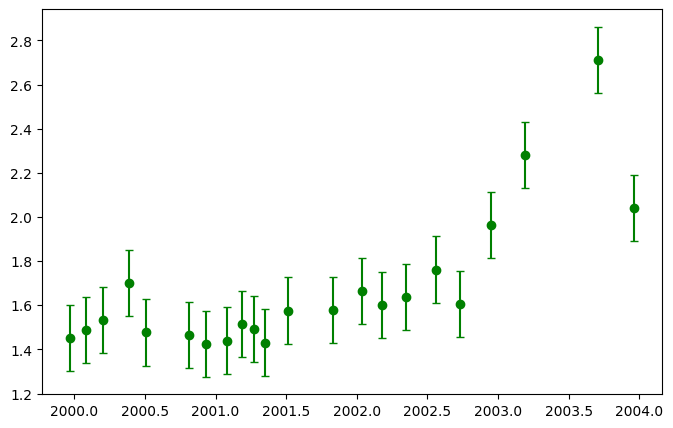

In [22]:
plt.figure(figsize=(8,5))
plt.errorbar(x,yobs,yerr=yerror,color='green',capsize=3,fmt="o")
plt.show()

## Exercise 1: Constant Fit:
Fit a constant to the data shown above, plot your constant fit, and compute its significance based on the chi-squared test following the two examples given earlier in the notebook. You can format this as three code cells: one to perform the fit, one to plot the fit, and one to compute the significance of the fit from its chi-squared value.

You should obtain a very low significance of 2.8e-11, meaning that a constant is an extremely poor fit to these data.

In [43]:
### YOUR CODE HERE TO PERFORM THE FIT!

#The constant fit.

def f(x, a):
    return a

pars, cov = curve_fit(f, x, yobs, sigma=yerror, absolute_sigma=True)
a = pars
cons_ycalc = np.full_like(yobs,a)



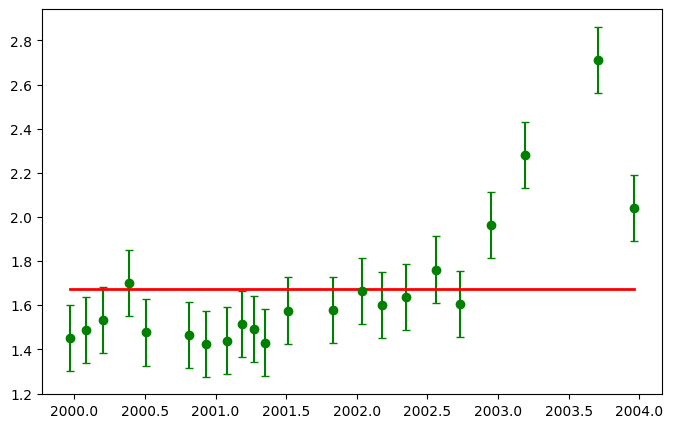

In [41]:
### YOUR CODE HERE TO PLOT THE FIT!''

#Plot the constant fit.
plt.figure(figsize=(8,5))
plt.errorbar(x,yobs,yerr=yerror,color='green',capsize=3,fmt="o")
plt.plot(x,ycalc,color='red',linewidth=2)
plt.show()

In [44]:
#Significance of the constant fit.
cons_chisqr = np.sum((yobs-cons_ycalc)**2/yerror**2)
cons_dof = yobs.shape[0]-1
cons_significance = 1.0-stats.chi2.cdf(cons_chisqr, cons_dof)
print(cons_significance)

2.8176572186566773e-11


## Exercise 2: Linear Fit:

Fit a linear function to the data shown above, plot your linear fit, and compute its significance based on the chi-squared test following the two examples given earlier in the notebook. You can format this as three code cells: one to perform the fit, one to plot the fit, and one to compute the significance of the fit from its chi-squared value.

You should obtain a low significance of 0.007, meaning that a linear function is a poor fit to these data as well.

In [47]:
### YOUR CODE HERE TO PERFORM THE FIT!

def f(x, a, b):
    return a + b*x

pars, cov = curve_fit(f, x, yobs, sigma=yerror, absolute_sigma=True)
a, b = pars
nsigma = np.sqrt(np.diag(cov))
lin_ycalc = a + b*x
# print (round(pars[1],2), "+/-", round(nsigma[1],2))



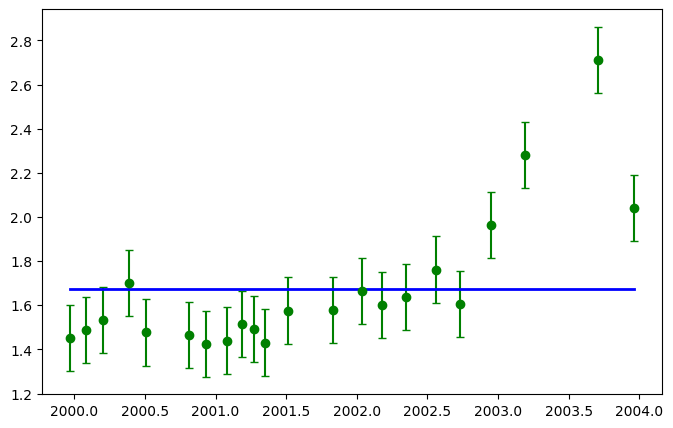

In [48]:
### YOUR CODE HERE TO PLOT THE FIT!
plt.figure(figsize=(8,5))
plt.errorbar(x,yobs,yerr=yerror,linestyle='none',color='green',capsize=3,fmt="o")
plt.plot(x,ycalc,color='blue',linewidth=2)
plt.show()

In [49]:
### YOUR CODE HERE TO COMPUTE THE SIGNIFICANCE!
lin_chisqr = np.sum((yobs - lin_ycalc) ** 2 / yerror ** 2)
lin_dof = len(yobs) - 2
lin_significance = 1.0 - stats.chi2.cdf(lin_chisqr, lin_dof)
print(round(lin_significance,3))

0.007


## Exercise 3: Quadratic Fit:
We found in Exercise 2 that a linear function was a poor fit to the data. The reasonable thing to do in this case would be to try a quadratic fit: y = a + b\*x + c\*x\*\*2, which would represent motion at constant acceleration.

Fit a quadratic function to the data shown above, plot your quadratic fit, and compute its significance based on the chi-squared test. You can format this as three code cells: one to perform the fit, one to plot the fit, and one to compute the significance of the fit from its chi-squared value.

You should obtain a significance of 0.213, meaning that a quadratic function provides an adequate fit to these data. Your quadratic fit should look like the exercise3.png file that is included with this notebook.
Apparenly something is causing the blob of plasma in this quasar jet to accelerate!

In [55]:
### YOUR CODE HERE TO PERFORM THE FIT!
def f(x, a, b, c):
    return a + b * x + c * x ** 2

pars, cov = curve_fit(f, x, yobs, sigma=yerror, absolute_sigma=True)
a, b, c = pars
quad_ycalc = f(x, a, b, c)

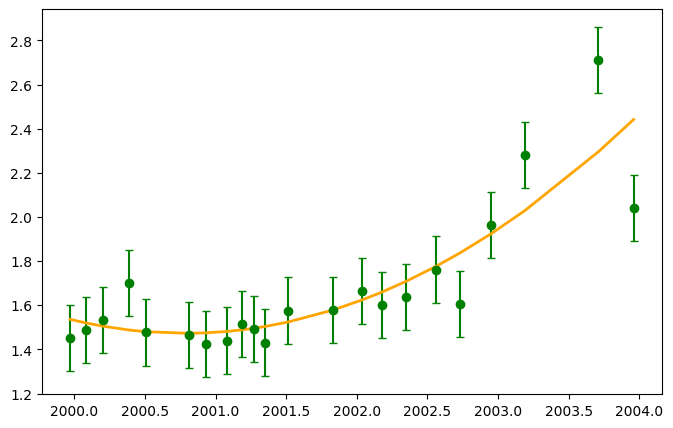

In [63]:
### YOUR CODE HERE TO PLOT THE FIT!
plt.figure(figsize=(8, 5))
plt.errorbar(x,yobs,yerr=yerror,linestyle='none',color='green',capsize=3,fmt="o")
plt.plot(x, quad_ycalc, color='orange', linewidth=2)
plt.show()

In [62]:
### YOUR CODE HERE TO COMPUTE THE SIGNIFICANCE!
quad_chisqr = np.sum((yobs - quad_ycalc) ** 2 / yerror ** 2)
quad_dof = len(yobs) - 3
quad_significance = 1.0 - stats.chi2.cdf(quad_chisqr, quad_dof)
print(round(quad_significance,3))

0.213


### We (myself, collaborators, and two Whittier students) published a huge dataset on accelerating quasar jets [here](https://ui.adsabs.harvard.edu/abs/2012ApJ...758...84P/abstract).